# Telco Customer Churn Analysis

*Data Science Fundamentals | Exam 1*

Author: Helene Schmelzer

Development Date: 2026-05-09

## Project Context

Customer churn is one of the main challenges faced by telecommunications companies. Understanding why customers leave a service helps businesses improve customer retention, reduce revenue loss, and optimize their services.

This project analyzes a telecom customer churn dataset through data cleaning and exploratory data analysis (EDA). The goal is to identify patterns, trends, and relationships between customer characteristics and churn behavior using Python-based data science tools.

---

## Data Dictionary

| Column | Description |
|---|---|
| customerID | Unique customer identifier |
| gender | Customer gender |
| SeniorCitizen | Indicates if the customer is a senior citizen (1 = Yes, 0 = No) |
| Partner | Whether the customer has a partner |
| Dependents | Whether the customer has dependents |
| tenure | Number of months the customer has stayed with the company |
| PhoneService | Whether the customer has phone service |
| MultipleLines | Whether the customer has multiple phone lines |
| InternetService | Type of internet service |
| OnlineSecurity | Whether the customer has online security |
| OnlineBackup | Whether the customer has online backup |
| DeviceProtection | Whether the customer has device protection |
| TechSupport | Whether the customer has tech support |
| StreamingTV | Whether the customer uses streaming TV |
| StreamingMovies | Whether the customer uses streaming movies |
| Contract | Type of customer contract |
| PaperlessBilling | Whether the customer uses paperless billing |
| PaymentMethod | Customer payment method |
| MonthlyCharges | Monthly amount charged to the customer |
| TotalCharges | Total amount charged to the customer |
| Churn | Whether the customer left the company |

---

## Project Objectives

- Clean and preprocess the dataset
- Identify and handle missing values
- Detect duplicates and inconsistencies
- Validate data types
- Explore customer churn patterns
- Create univariate and multivariate visualizations
- Extract insights from customer behavior

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

---

## Dataset

Dataset source:  
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

---

## Repository Structure

```text
fundamentos-data-science-telco-churn/
│
├── data/
├── notebooks/
├── images/
├── README.md
├── requirements.txt
└── .gitignore
```

---

## Loads and First Exploration

### Config and Imports

In [49]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Style
plt.style.use('dark_background')
sns.set_style('darkgrid')

### Data Loading

The dataset is loaded into a Pandas DataFrame from a CSV file:

In [50]:
file_name = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
file_path = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(file_path)

The dataset was explored to better understand its structure and identify possible data quality issues.

In [51]:
print(f"{file_name}")
print(f"Shape: {df.shape}")
print(f"→ {df.shape[0]} rows, {df.shape[1]} columns\n")

WA_Fn-UseC_-Telco-Customer-Churn.csv
Shape: (7043, 21)
→ 7043 rows, 21 columns



### First and Last Records

In [52]:
# Observation:
# The dataset contains customer demographic information, telecom services,
# billing details, and churn status. Each row represents one customer.
# Variables include contract type, internet services, payment methods,
# monthly charges, total charges, and whether the customer left the company.
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [53]:
# Observation:
# The dataset appears consistent in its structure and contains a mix of
# customer profile, service usage, and financial information.
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


### Dataset Structure

In [54]:
# Observation:
# The dataset contains 7,043 customer records and 21 variables.
# Most columns are categorical variables stored as strings, while tenure,
# SeniorCitizen, and MonthlyCharges are numerical variables.
#
# There are no visible missing values in the dataset at this stage.
# However, the TotalCharges column is stored as an object (string) instead
# of a numeric type, which suggests possible formatting issues or hidden
# missing values that will need further cleaning.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Descriptive Statistics

In [55]:
# Observation:
# The dataset shows a wide variation in customer tenure, ranging from 0 to 72 months,
# which indicates the presence of both new and long-term customers.
#
# Monthly charges also vary considerably, suggesting different service plans
# and pricing levels among customers.
#
# The SeniorCitizen variable is binary (0 or 1), where most customers are
# not senior citizens based on the median and quartile values.
df.describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


### Missing Values

In [56]:
# No missing values are detected in the dataset based on the current inspection.
# However, the TotalCharges column is still stored as a string data type,
# which may indicate the presence of hidden missing values or blank spaces
# that are not identified as standard null values.
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Duplicate Records

In [57]:
# Observation:
# No exact duplicated rows were found in the dataset.
# This indicates that each record appears to represent a unique customer entry.
n_duplicated = df.duplicated().sum()
print(f"Exact duplicated rows before cleaning: {n_duplicated}")

Exact duplicated rows before cleaning: 0


### Categorical Value Consistency

In [58]:
# Observation:
# The categorical variables appear consistent, with standardized values such as
# "Yes" and "No" across the dataset. No obvious formatting inconsistencies
# (such as uppercase/lowercase variations or misspellings) were detected.
#
# Some variables contain additional categories like "No internet service"
# or "No phone service", which provide more detailed service information.
#
# The TotalCharges column is still stored as a string and will require
# conversion to a numeric data type during the cleaning process.
for col in df.columns:
    print(col, df[col].unique()[:10])

customerID <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU']
Length: 10, dtype: str
gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
SeniorCitizen [0 1]
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
tenure [ 1 34  2 45  8 22 10 28 62 13]
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtyp

## Data Cleaning

A copy of the original dataset is created to preserve the raw data before applying any cleaning operations.

In [59]:
df_clean = df.copy()

### Fixing the `TotalCharges` Column

In [60]:
# Replace blank spaces with NaN
df_clean['TotalCharges'] = df_clean['TotalCharges'].replace(' ', np.nan)

# Convert column to numeric
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'])

#### Verifying Missing Values

In [61]:
df_clean.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

#### Handling Missing Values

In [62]:
# Fill missing values using the median
median_total = df_clean['TotalCharges'].median()

df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(median_total)

#### Verifying Missing Values After Cleaning

In [63]:
df_clean.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### Verifying Data Types

In [64]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

After replacing blank spaces with `NaN` values, a missing value analysis revealed 11 missing entries in the `TotalCharges` column during its conversion from string to numeric format. These missing values were imputed using the median to preserve the distribution of the data and reduce the influence of outliers. A final completeness check confirmed that no missing values remain in the dataset. This ensures the dataset is fully clean and ready for further analysis.

### Fixing the `SeniorCitizen` column

In [72]:
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [73]:
df_clean['SeniorCitizen'] = df_clean['SeniorCitizen'].astype('object')

In [76]:
df_clean['SeniorCitizen'].unique()

array(['No', 'Yes'], dtype=object)

#### Verifying Data Types After Cleaning

In [75]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [74]:
df_clean.dtypes.value_counts()

str        17
float64     2
object      1
int64       1
Name: count, dtype: int64

A comprehensive data quality and type consistency check was performed across all variables. No invalid or out-of-range values were identified, as all observations were consistent with their expected domains. In addition, all variables were verified against the data dictionary to ensure appropriate data types, with numerical features (tenure, MonthlyCharges, TotalCharges) maintained as numeric formats and categorical variables stored as object/string types. The SeniorCitizen variable was recoded from a numeric binary format into a categorical representation (Yes/No) to improve interpretability. Overall, the dataset is fully consistent, well-structured, and suitable for further analysis and modeling.

## Data Visualization

### Churn Distribution

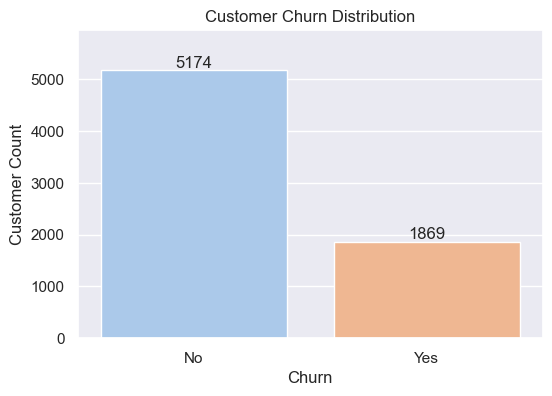

In [66]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='Churn',
    hue='Churn',
    data=df_clean,
    palette='pastel',
    legend=False
)

# Add labels
for container in ax.containers:
    ax.bar_label(container)

# Dynamic top padding
max_count = df_clean['Churn'].value_counts().max()
ax.set_ylim(0, max_count * 1.15)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Customer Count')

plt.show()

Interpretation:

Most customers remained with the company, while a smaller but significant group of customers left the service. This indicates that customer retention is generally stable, although churn remains an important business concern.

### Monthly Charges Distribution

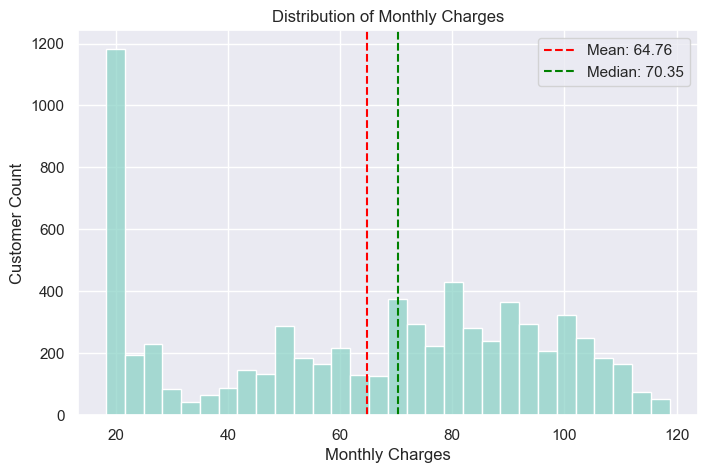

In [68]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df_clean,
    x='MonthlyCharges',
    bins=30
)

# Mean and median
mean_charge = df_clean['MonthlyCharges'].mean()
median_charge = df_clean['MonthlyCharges'].median()

plt.axvline(
    mean_charge,
    color='red',
    linestyle='--',
    label=f'Mean: {mean_charge:.2f}'
)

plt.axvline(
    median_charge,
    color='green',
    linestyle='--',
    label=f'Median: {median_charge:.2f}'
)

plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Customer Count')

plt.legend()

plt.show()

Interpretation:

Monthly charges are distributed across a wide range of values, with many customers concentrated in medium and high pricing ranges. 

The mean and median values are relatively close, suggesting that the distribution is moderately balanced without extreme skewness.

### Churn by Contract Type

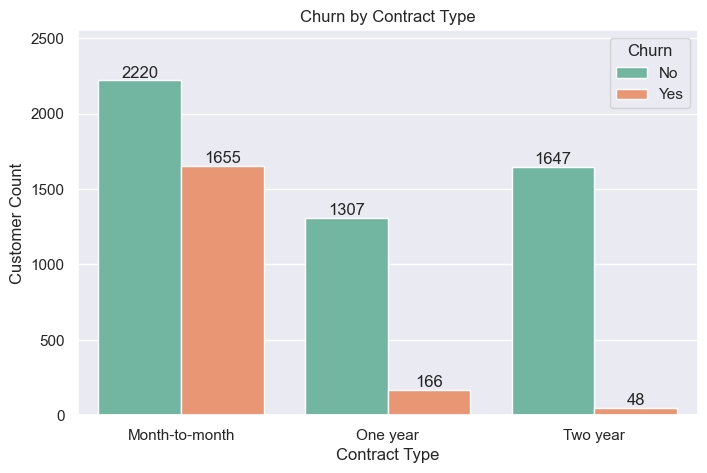

In [70]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_clean,
    x='Contract',
    hue='Churn',
    palette='Set2'
)

# Add labels
for container in ax.containers:
    ax.bar_label(container)

# Add padding on top
max_height = max([p.get_height() for container in ax.containers for p in container])
ax.set_ylim(0, max_height * 1.15)  # 15% extra space

plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Customer Count')

plt.legend(title='Churn')

plt.show()

Interpretation:

Customers with month-to-month contracts show the highest churn levels, while customers with one-year and two-year contracts are more likely to remain with the company.

This suggests that longer contracts may improve customer retention and reduce churn risk.

### Monthly Charges vs Tenure by Churn

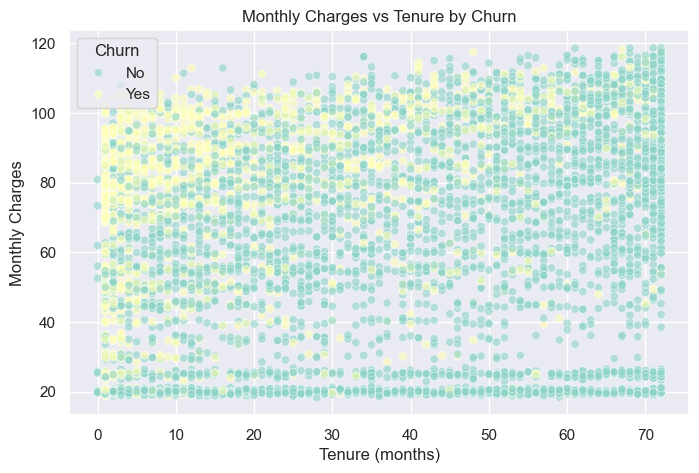

In [71]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_clean,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn',
    alpha=0.6
)

plt.title('Monthly Charges vs Tenure by Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges')

plt.show()

Interpretation:

Churn is most likely among customers with low tenure and relatively higher monthly charges, suggesting early-stage dissatisfaction or price sensitivity during onboarding.

## Final Summary

A comprehensive data preprocessing and exploratory analysis process was carried out to ensure data quality, consistency, and analytical readiness. Missing values were identified in the `TotalCharges` column following its conversion from string to numeric format and were imputed using the median to preserve the distribution and reduce the influence of outliers. A validation check confirmed the absence of invalid or out-of-range values across all variables.

All variables were reviewed against the data dictionary to ensure appropriate data types, with numerical features maintained in numeric formats and categorical variables stored as object/string types. The `SeniorCitizen` variable was recoded from a numeric binary format into a categorical representation (Yes/No) to improve interpretability.

Following data preparation, an exploratory data analysis was conducted through four key visualizations: Churn Distribution, Monthly Charges Distribution, Churn vs Contract Type, and Monthly Charges vs Tenure by Churn. These plots were used to understand overall churn behavior, pricing patterns, contract effects, and the relationship between customer tenure and monthly charges.

Overall, the dataset is complete, consistent, and fully aligned with the expected schema, making it suitable for further analysis and modeling.

### Insights

The exploratory analysis revealed clear patterns related to customer churn. The churn distribution showed an imbalance between retained and churned customers, indicating that churn is a significant but not majority outcome in the dataset. Analysis of monthly charges suggested variation in pricing exposure across customers, with churned users tending to appear more frequently in higher charge ranges.

The relationship between churn and contract type highlighted that customers with shorter-term contracts were more likely to churn, suggesting that contract duration plays a key role in customer retention. Finally, the relationship between monthly charges and tenure by churn status showed that churn is more concentrated among newer customers, particularly during the early stages of their tenure, while long-tenure customers were more likely to remain retained regardless of charge level.

Overall, the findings suggest that churn is primarily influenced by customer tenure and contract structure, with pricing potentially acting as an additional contributing factor. These insights can support targeted retention strategies, particularly focused on early-stage customers and short-term contract users.

## Acknowledgements

I would like to express my appreciation to my instructors for their guidance, support, and for trusting my ability to complete this project successfully. Their encouragement has been an important part of this learning process and has helped me stay motivated throughout the development of the analysis.

I also acknowledge the use of AI-based assistance tools during the development of this project, which supported tasks such as improving writing clarity, reviewing code, and refining analytical explanations. This assistance was used as a supplementary resource, while all final decisions, interpretations, and analyses were independently developed.

Finally, this experience reinforced the importance of planning the workflow in reverse—from final output to initial steps—in order to better manage time and ensure timely submission of the work.